In [1]:
import pandas as pd
import nltk
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy
from scipy.sparse import hstack
import numpy as np
import spacy
import re


In [2]:
#punkt è modello di tokenizzatore
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet = True)
#POS tokenizer per riconoscere grammaticalmente le parti dl discorso
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

True

In [3]:
#Load data
df = pd.read_csv('../Dati/Raw/articles_clean.csv')

#Funzione per selezionare il primo quartile di un articolo (v. paper reference)
def truncate_to_25pct(text):
    if not isinstance(text, str): return ""
    sentences = nltk.sent_tokenize(text) #Tokenizzazione per frasi (sentences)
    limit = max(1, len(sentences) // 4)
    return " ".join(sentences[:limit])

df.head()


,article_id,topic_id,date,original_orientation,binary_label,full_text
0,61d9f869-d054-4938-9c9c-6351777db2ad,"Powerful Earthquakes Hit Venezuela, USGS Estim...",NaN,left,1,"More than 900 people have been injured, but th..."
1,f1bb9659-50f4-4521-930e-c2158a2281af,"Powerful Earthquakes Hit Venezuela, USGS Estim...",NaN,center,0,Tremors Kill At Least 164 People in Venezuela ...
2,d230406b-a562-4d90-b5d4-5f3ed51fd256,"Powerful Earthquakes Hit Venezuela, USGS Estim...",NaN,right,1,Venezuela was rocked Wednesday afternoon by it...
3,e1787ee3-88e4-4156-adb1-32a097da0a16,Supreme Court Rules Prison Guards Cannot Be Su...,NaN,left,1,Exterior view of the U.S. Supreme Court Buildi...
4,6e6aa0bb-f209-42dc-8918-4c1a056d9f8b,Supreme Court Rules Prison Guards Cannot Be Su...,NaN,center,0,The US Supreme Court has ruled that a former L...


In [4]:
#Trovo articoli troppo corti ed elimino l'intera tripletta di cui fa parte
df['word_count'] = df['full_text'].str.split().str.len()
invalid_topics = df[df['word_count'] < 50]['topic_id'].unique()  #per individuare la tripletta
df_clean = df[~df['topic_id'].isin(invalid_topics)]

#Sanity check
print(f"Topics removed: {len(invalid_topics)}")
print(f"Residual topics: {df_clean['topic_id'].nunique()}")
df['full_text'] = df['full_text'].apply(truncate_to_25pct)


df['full_text'] = df['full_text'].replace(r'\s+', ' ', regex=True).str.strip()

Topics removed: 5
Residual topics: 64


In [5]:
#spaCy per fare riconoscere entità, organizzazioni (entities), tutti termini difficilmente presenti in un dizionaio standard
nlp = spacy.load("en_core_web_sm", disable=["parser", "lemmatizer"]) #Assumiamo sia già installato su si usa environment

def mask_named_entities(text):
    doc = nlp(text)
    #Replace every named entity with label (e.g., PERSON, ORG,...)
    for ent in reversed(doc.ents):
        text = text[:ent.start_char] + ent.label_ + text[ent.end_char:]
    return text

In [6]:
#Applica la mask appena costruita per le 'entities'
df['full_text'] = df['full_text'].apply(mask_named_entities)

In [7]:
def rigorous_clean(text):
    text = str(text)
    #Remove everything except alphanumeric, spaces, and basic punctuation
    text = re.sub(r'[^\w\s.,!?]', '', text)
    #Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [8]:
df['full_text'] = df['full_text'].apply(rigorous_clean)

In [9]:
# POS Tagging extraction function --> cioè riconosce verbo, soggetto, ecc...
def get_pos_tags(text):
    tokens = nltk.word_tokenize(text)
    tags = nltk.pos_tag(tokens)
    return " ".join([tag for word, tag in tags])

In [10]:
#Extract POS tags
df['pos_text'] = df['full_text'].apply(get_pos_tags)

In [11]:
#Usiamo gli n-grammi (2-4) come struttura di codifica
#In particolare usiamo TF-IDF per creare features stilometriche (v. paper)
char_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 4), min_df=0.05, strip_accents='unicode')
char_features = char_vectorizer.fit_transform(df['full_text'].astype(str))

#N-grammi (1-2) sulla struttura del discorso (POS)
pos_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=0.05) #minimo di frequenza degli n-grammi
pos_features = pos_vectorizer.fit_transform(df['pos_text'])

X = hstack([char_features, pos_features])

print(f"Total number of stylometric features: {X.shape[1]}")

Total number of stylometric features: 6521


In [12]:
#Obiettivo: vedere, in base a TF-IDF quanto sono prominenti le strutture (suona meglio in inglese ma ok),
#sia a livello di caratteri (char) che a livello di parti del discorso (pos)

#Uniamo dizionari char e pos
char_names = char_vectorizer.get_feature_names_out()
pos_names = pos_vectorizer.get_feature_names_out()
all_names = np.concatenate([char_names, pos_names])

#TF-IDF Medio across i vari articoli
mean_scores = np.array(X.mean(axis=0)).flatten()

#DataFrame per visualizzare risultati
feature_prominence = pd.DataFrame({
    'feature': all_names,
    'prominence': mean_scores
}).sort_values(by='prominence', ascending=False)

print(feature_prominence.head(20))

      feature  prominence
6337      nnp    0.407180
6317       nn    0.377366
6283       in    0.324009
6269       dt    0.238028
6358      nns    0.163746
6296       jj    0.158097
1675       e     0.158013
533         t    0.126513
6442      vbd    0.115429
6320    nn in    0.114776
6345  nnp nnp    0.114346
6289   in nnp    0.112964
6273    dt nn    0.112659
5           a    0.106903
2938       in    0.105936
5081       s     0.100047
6284    in dt    0.098808
5622       th    0.097287
6379      prp    0.091258
6426       vb    0.086099


In [13]:
######EDA############

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
#from wordcloud import WordCloud #Reminder per futuri grafici post risultati finali

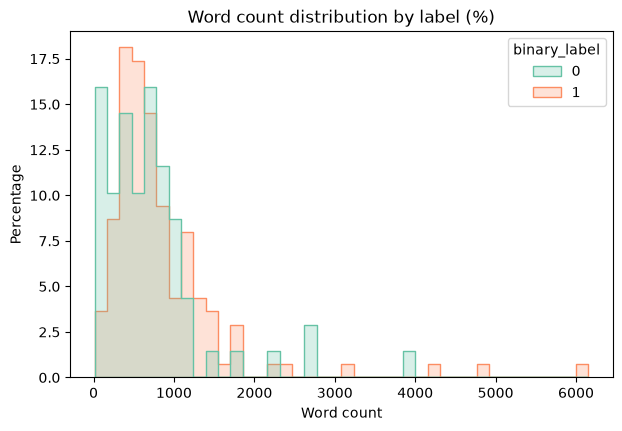

In [15]:
#Article length — histogram by label
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(data=df, x='word_count', hue='binary_label', kde=False,
             element='step', bins=40, stat='percent', common_norm=False, ax=ax, palette="Set2")

ax.set(title="Word count distribution by label (%)", xlabel="Word count", ylabel="Percentage")


fig.savefig("../Risultati/word_count_distribution_by_label.png", dpi=300, bbox_inches="tight")
plt.show()

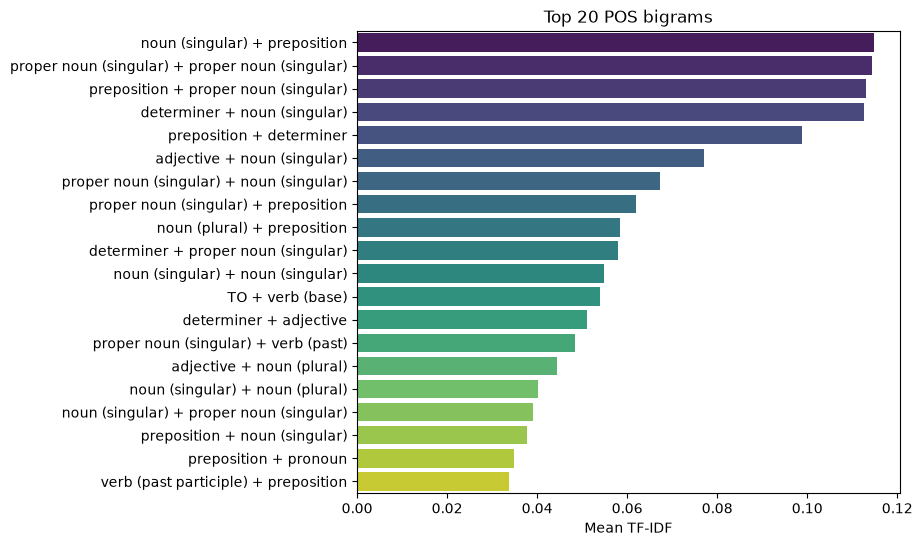

In [16]:
#Top POS n-grams (TF-IDF) — ONLY n > 1 (bigrams)

pos_only = feature_prominence[feature_prominence['feature'].isin(pos_names)].copy()

#n-grams with n > 1 --> bigrams
pos_only_bigrams = pos_only[pos_only['feature'].str.contains(r'\s')]

pos_prominence = pos_only_bigrams.sort_values(by='prominence', ascending=False).head(20)

#Now translate the acronysmsin the POS dictionary
pos_map = {
    "NN": "noun (singular)",
    "NNS": "noun (plural)",
    "NNP": "proper noun (singular)",
    "NNPS": "proper noun (plural)",
    "VB": "verb (base)",
    "VBD": "verb (past)",
    "VBG": "verb (gerund)",
    "VBN": "verb (past participle)",
    "VBP": "verb (non-3rd person singular present)",
    "VBZ": "verb (3rd person singular present)",
    "JJ": "adjective",
    "JJR": "adjective (comparative)",
    "JJS": "adjective (superlative)",
    "RB": "adverb",
    "RBR": "adverb (comparative)",
    "RBS": "adverb (superlative)",
    "IN": "preposition",
    "DT": "determiner",
    "PRP": "pronoun",
    "PRP$": "possessive pronoun",
    "CC": "coordinating conjunction",
    "CD": "cardinal number",
}

def decode_pos_bigram(bigram):
    tags = [t.strip().upper() for t in bigram.split()]
    return " + ".join([pos_map.get(t, t) for t in tags])

pos_prominence["readable_feature"] = pos_prominence["feature"].apply(decode_pos_bigram)

fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(
    data=pos_prominence,
    x='prominence',
    y='readable_feature',
    hue='readable_feature',
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set(
    title="Top 20 POS bigrams",
    xlabel="Mean TF-IDF",
    ylabel=""
)


fig.savefig("../Risultati/TOP_20_POS_bigrams.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
#Saving objects
import joblib
import pandas as pd
import json


# =========================
# 1. Save final cleaned dataset
# =========================
df.to_csv("../Dati/Processed/dataset_processed_quantile1_sentences.csv", index=False)

# =========================
# 2. Save TF-IDF vectorizers
# =========================
joblib.dump(
    char_vectorizer,
    "../Dati/Processed/artifacts/char_vectorizer.pkl"
)

joblib.dump(
    pos_vectorizer,
    "../Dati/Processed/artifacts/pos_vectorizer.pkl"
)

# =========================
# 3. Save feature names
# =========================
pd.Series(char_names).to_csv(
    "../Dati/Processed/artifacts/char_feature_names.csv",
    index=False
)

pd.Series(pos_names).to_csv(
    "../Dati/Processed/artifacts/pos_feature_names.csv",
    index=False
)

# =========================
# 4. Save feature importance / prominence
# =========================
feature_prominence.to_csv(
    "../Dati/Processed/artifacts/feature_prominence.csv",
    index=False
)

# =========================
# 5. Save POS mapping 
# =========================

with open("../Dati/Processed/artifacts/pos_map.json", "w") as f:
    json.dump(pos_map, f, indent=4)

print("All artifacts saved successfully.") 

All artifacts saved successfully.
